### Maestría en Ciencia de Datos
### PIA Datos Masivos 2025
Gema Guerra Valdez - 1819110

In [1]:
import os
import sys

# Force Spark to use the exact Python executable running this notebook
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# Point to your Spark installation
os.environ['SPARK_HOME'] = r'C:\spark'

# Windows-specific: Spark needs Hadoop binaries (winutils.exe)
# Ensure you have winutils.exe in C:\hadoop\bin
os.environ['HADOOP_HOME'] = r'C:\hadoop' 
os.environ['PATH'] += os.pathsep + r'C:\hadoop\bin'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PIA_Gema") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.nio=ALL-UNNAMED " +
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.nio=ALL-UNNAMED " +
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED") \
    .getOrCreate()

sc = spark.sparkContext


In [5]:
pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/18/78/08cec00ea05fd2469f9395da0306bb368c4ed275693be8d31473eafaf90c/kagglehub-1.0.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 165.2 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 238.6 kB/s eta 0:00:00
  Obtaining dependency information for pyyaml from https://files.pythonhosted.org/packages/da/e3/ea007450a105ae919a72393cb06f122f288ef60bba2dc64b26e2646fa315/pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/70.6 kB ? eta -:--:--
   ---------------------------------------- 70.6/70.6 kB 1.3 MB/s eta 0:0


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hrokrin/the-largest-diamond-dataset-currely-on-kaggle")

print("Path to dataset files:", path)

c:\Users\gema2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.16M/4.16M [00:04<00:00, 1.07MB/s]

Extracting files...


Path to dataset files: C:\Users\gema2\.cache\kagglehub\datasets\hrokrin\the-largest-diamond-dataset-currely-on-kaggle\versions\1


In [12]:
path = r"C:\Users\gema2\.cache\kagglehub\datasets\hrokrin\the-largest-diamond-dataset-currely-on-kaggle\versions\1\diamonds.csv"

# Leer el dataset
df = spark.read.csv(path, header=True, inferSchema=True)

# Ver esquema de columnas
df.printSchema()



root
 |-- _c0: integer (nullable = true)
 |-- cut: string (nullable = true)
 |-- color: string (nullable = true)
 |-- clarity: string (nullable = true)
 |-- carat_weight: double (nullable = true)
 |-- cut_quality: string (nullable = true)
 |-- lab: string (nullable = true)
 |-- symmetry: string (nullable = true)
 |-- polish: string (nullable = true)
 |-- eye_clean: string (nullable = true)
 |-- culet_size: string (nullable = true)
 |-- culet_condition: string (nullable = true)
 |-- depth_percent: double (nullable = true)
 |-- table_percent: double (nullable = true)
 |-- meas_length: double (nullable = true)
 |-- meas_width: double (nullable = true)
 |-- meas_depth: double (nullable = true)
 |-- girdle_min: string (nullable = true)
 |-- girdle_max: string (nullable = true)
 |-- fluor_color: string (nullable = true)
 |-- fluor_intensity: string (nullable = true)
 |-- fancy_color_dominant_color: string (nullable = true)
 |-- fancy_color_secondary_color: string (nullable = true)
 |-- fancy

In [25]:
df.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'eye_clean',
 'culet_size',
 'culet_condition',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 'total_sales_price']

In [13]:
# Mostrar primeras filas
df.show(10)

+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-------------+-----------+----------+----------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------+-----------------+
|_c0|  cut|color|clarity|carat_weight|cut_quality|lab| symmetry|   polish|eye_clean|culet_size|culet_condition|depth_percent|table_percent|meas_length|meas_width|meas_depth|girdle_min|girdle_max|fluor_color|fluor_intensity|fancy_color_dominant_color|fancy_color_secondary_color|fancy_color_overtone|fancy_color_intensity|total_sales_price|
+---+-----+-----+-------+------------+-----------+---+---------+---------+---------+----------+---------------+-------------+-------------+-----------+----------+----------+----------+----------+-----------+---------------+--------------------------+---------------------------+--------------------+---------------------

In [11]:
df.count()

219703

### Limpieza de Datos

In [ ]:
from pyspark.sql.functions import col, when, count

# Separar columnas por tipo
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float")]
string_cols = [c for c, t in df.dtypes if t not in ("int", "double", "float")]

# Contar valores faltantes en columnas numéricas (None y NaN)
missing_numeric = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in numeric_cols
])

# Contar valores faltantes en columnas string (None y "Unknown")
missing_string = df.select([
    count(when(col(c).isNull()  | (col(c) == "unknown") | (col(c) == "None") , c)).alias(c)
    for c in string_cols
])

print("Valores faltantes en columnas numéricas:")
missing_numeric.show()



Valores faltantes en columnas numéricas:
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+
|_c0|carat_weight|depth_percent|table_percent|meas_length|meas_width|meas_depth|total_sales_price|
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+
|  0|           0|            0|            0|          0|         0|         0|                0|
+---+------------+-------------+-------------+-----------+----------+----------+-----------------+

Valores faltantes en columnas string:
+---+-----+-------+-----------+---+--------+------+
|cut|color|clarity|cut_quality|lab|symmetry|polish|
+---+-----+-------+-----------+---+--------+------+
|  0| 9162|      0|      60607|  0|       0|     0|
+---+-----+-------+-----------+---+--------+------+



In [33]:
df_limpio= df.drop(
 'eye_clean',
 'culet_size',
 'culet_condition',
 'girdle_min',
 'girdle_max',
 'fluor_color',
 'fluor_intensity',
 'fancy_color_dominant_color',
 'fancy_color_secondary_color',
 'fancy_color_overtone',
 'fancy_color_intensity',
 )

In [40]:
df_limpio.dropna()

df_limpio = df.filter((col("color") != "unknown") & (col("cut_quality") != "unknown"))

df_limpio.count()

158991

In [38]:
# Contar valores faltantes en columnas string (None y "Unknown")
missing_string = df_limpio.select([
    count(when(col(c).isNull()  | (col(c) == "unknown") | (col(c) == "None") , c)).alias(c)
    for c in string_cols
])

print("Valores faltantes en columnas string:")
missing_string.show()

Valores faltantes en columnas string:
+---+-----+-------+-----------+---+--------+------+
|cut|color|clarity|cut_quality|lab|symmetry|polish|
+---+-----+-------+-----------+---+--------+------+
|  0|    0|      0|          0|  0|       0|     0|
+---+-----+-------+-----------+---+--------+------+



### Análisis Exploratorio

In [51]:
df_limpio.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'total_sales_price']

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

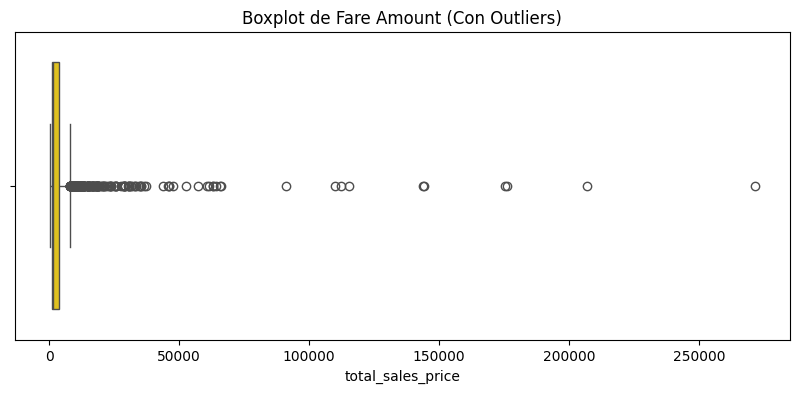

In [49]:
df_sample = df_limpio.select("total_sales_price").sample(False, 0.01).toPandas()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sample["total_sales_price"], color="gold")
plt.title("Boxplot de Fare Amount (Con Outliers)")
plt.show()

### Preparación de características

In [ ]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.feature import StandardScaler

In [52]:
indexer = StringIndexer(
    inputCols=["cut", "color", "clarity", 'cut_quality','lab','symmetry','polish'],
    outputCols=["cut_index", "color_index", "clarity_index",'cut_quality_index','lab_index','symmetry_index','polish_index']
)

df_indexed = indexer.fit(df_limpio).transform(df_limpio)
df_indexed.show(5)

+---+-----+-----+-------+------------+-----------+---+---------+---------+-------------+-------------+-----------+----------+----------+-----------------+---------+-----------+-------------+-----------------+---------+--------------+------------+
|_c0|  cut|color|clarity|carat_weight|cut_quality|lab| symmetry|   polish|depth_percent|table_percent|meas_length|meas_width|meas_depth|total_sales_price|cut_index|color_index|clarity_index|cut_quality_index|lab_index|symmetry_index|polish_index|
+---+-----+-----+-------+------------+-----------+---+---------+---------+-------------+-------------+-----------+----------+----------+-----------------+---------+-----------+-------------+-----------------+---------+--------------+------------+
|  0|Round|    E|   VVS2|        0.09|  Excellent|IGI|Very Good|Very Good|         62.7|         59.0|       2.85|      2.87|      1.79|              200|      0.0|        0.0|          3.0|              0.0|      1.0|           1.0|         1.0|
|  1|Round| 

In [53]:
df_indexed.columns

['_c0',
 'cut',
 'color',
 'clarity',
 'carat_weight',
 'cut_quality',
 'lab',
 'symmetry',
 'polish',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'total_sales_price',
 'cut_index',
 'color_index',
 'clarity_index',
 'cut_quality_index',
 'lab_index',
 'symmetry_index',
 'polish_index']

In [68]:
input_cols = [
 'carat_weight',
 'depth_percent',
 'table_percent',
 'meas_length',
 'meas_width',
 'meas_depth',
 'cut_index',
 'color_index',
 'clarity_index',
 'cut_quality_index',
 'lab_index',
 'symmetry_index',
 'polish_index']


In [69]:
assembler = VectorAssembler().setInputCols(input_cols).setOutputCol("vector_unificado")
df_vector = assembler.transform(df_indexed)

In [70]:
scaler = StandardScaler(inputCol="vector_unificado", outputCol="features_scaled", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

In [71]:
from pyspark.ml.feature import UnivariateFeatureSelector

In [75]:
selector = UnivariateFeatureSelector(featuresCol="features_scaled", labelCol= 'total_sales_price', outputCol="selectedFeatures")
selector.setFeatureType("continuous").setLabelType("continuous").setSelectionThreshold(7)

UnivariateFeatureSelector_66a73ce15c16

In [76]:
selector_model = selector.fit(df_scaled)
selected_df = selector_model.transform(df_scaled)

In [77]:
# Extraer los nombres de las variables elegidas
indices = selector_model.selectedFeatures
print(f"Variables seleccionadas: {[input_cols[i] for i in indices]}")

Variables seleccionadas: ['carat_weight', 'meas_length', 'meas_width', 'meas_depth', 'cut_index', 'cut_quality_index', 'lab_index']


### Modelo de Predicción

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator